# Creation of proteins and methods

The aim of this notebook is to extract all the necessary information of each protein, like an identity card (ID), to simplify afterward the manipulation of the protein objects. Then methods will be added to interact with those latter objects.

## I/ Importation

In [ ]:
# Not needed
import sys
sys.path.append("/Users/gaspard/PyCharmMiscProject/PIMS/src")
sys.path.append("/Users/gaspard/PyCharmMiscProject/PIMS/.pixi")
sys.path.append("/Users/gaspard/PyCharmMiscProject/PIMS/PIMS project/subjects")
from pathlib import Path

from tqdm import tqdm

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import matplotlib.colors as mcolors

import warnings
import re
import numpy as np

import gudhi as gd
from gudhi import DelaunayCechComplex
from gudhi.wasserstein import wasserstein_distance
from sklearn.manifold import MDS
from sklearn.metrics import euclidean_distances

from Bio.PDB import PDBParser
from Bio.PDB.PDBExceptions import PDBConstructionWarning
from tp_pims.config import TP_PATH
from tp_pims.vizualize_filtration import extract_ca_atom_pos

## II/ Creation of a protein class

Creation of an object representing proteins which stores their topological data, making the manipulation of proteins easier, acting like an identity card for each protein

The methods will allow the latter ID to be completed with the needed info

In [ ]:
# Class representing proteins and their topological data (TDA)
class Protein:

    def __init__(self, code, sequence=None, data_folder=None):
       # Basic info
        self.code = code
        self.role = None
        self.sequence = sequence
        self.length = len(sequence) if sequence else None

        # Management of the folder and files path
        # !!! Mays be an issue, please check your own path
        if data_folder is None:
            self.data_folder = TP_PATH / "subjects"
        else:
            self.data_folder = Path(data_folder)

        self.file_name = f"AF-{code}-F1-model_v6.pdb"
        self.path = self.data_folder / self.file_name
        self.file_exist = self.path.exists()

        # Futur attributes, that will be stored in the protein, to be easier to access
        self._type = None
        self._organism = None
        self._structure = None
        self._pos_ca = None
        self._simplex_tree = None
        self._diagram_raw = None
        self._diagram_np = None
        self._WD = None
        self._WDS = None
        self._constellation_coo = None

    # ----- I. Info obtention -----

    # Return the type of protein
    def get_prot_type_from_pdb(self):
            if self._type is None:
                self._type = extract_prot_type_from_pdb(self.path)
            return self._type

    # Return the organism from which the protein as been extracted
    def get_organism_from_pdb(self):
            if self._organism is None:
                self._organism = extract_organism_from_pdb(self.path)
            return self._organism

    # Return the 3D structure of the protein, as in the notebook of Jules Fauchon (cf. TP1)
    def get_structure(self):
        if self._structure is None:
            if not self.file_exist:
                raise FileNotFoundError(f"File not found for {self.code}: {self.path}")
            # Mode PERMISSIVE=1 to tackle crashing issues on small anomalies form PDB files
            warnings.filterwarnings("ignore", category=PDBConstructionWarning)
            parser = PDBParser(PERMISSIVE=1, QUIET=1)
            self._structure = parser.get_structure(id=self.code, file=self.path.open("r"))
        return self._structure

    # Get the coordinates of alpha carbon (CA) (can be modified to get other kind of atoms)
    def get_ca_coordinates(self, verbose=True):
        if self._pos_ca is None:
            structure = self.get_structure()
            # Extraction completed thanks to the already existing function (cf. TP1)
            self._pos_ca = extract_ca_atom_pos(list(structure.get_residues()))

        if verbose:
            f"CA coordinates have been successfully extracted, here's the coordinates of the first CA : {self._pos_ca[0]}"

        return self._pos_ca

    # Creation of a simplicial complex (Delaunay-Cech) and calculation of the persistence
    def get_simplex_tree(self):
        if self._simplex_tree is None:
            if self._pos_ca is None:
                raise RuntimeError(f"CA coordinates have not been extracted yet, please run get_ca_coordinates first")
            pos_ca = self._pos_ca
            cech_cs = DelaunayCechComplex(points=pos_ca)
            self._simplex_tree = cech_cs.create_simplex_tree()
            self._simplex_tree.compute_persistence()
        return self._simplex_tree

    # Return the barcode in 1D (containing values needed for persistance and barcode diagram)
    def get_raw_barcode(self, dimension=1):
        if self._diagram_raw is None:
            if self._simplex_tree is None:
                simplex_tree = self.get_simplex_tree()
            else :
                simplex_tree = self._simplex_tree
            self._diagram_raw = simplex_tree.persistence_intervals_in_dimension(dimension)
        return self._diagram_raw

    # Return a numpy dataframe later used in the Wasserstein distance calculation
    def get_diagram_numpy(self, decimals=3):
        if self._diagram_np is None:
            diagram = self.get_raw_barcode()  # shape (N, 2), already dim=1

            if len(diagram) == 0:
                self._diagram_np = np.array([], dtype=float).reshape(0, 2)
            else:
                mask = np.isfinite(diagram).all(axis=1)
                self._diagram_np = np.round(diagram[mask].astype(float), decimals=decimals)

        return self._diagram_np

    # Calculates the Wasserstein distance between two proteins
    def get_wasserstein_distance(self, other_protein, order=2):
        from gudhi.wasserstein import wasserstein_distance

        if self._diagram_np is None:
            raise RuntimeError(f"Values seems to be missing, please run get_diagram_numpy first")
        diag1 = self._diagram_np
        diag2 = other_protein._diagram_np

        if len(diag1) == 0:
            print(f"The diagram is empty for {self.code}")
            return None
        elif len(diag2) == 0:
            print(f"The diagram is empty for {other_protein.code}")
            return None

        return wasserstein_distance(diag1, diag2, order=order)

    # ----- II. Graphic representations -----

    # Return the standard persistence diagram
    def plot_diagram(self):
        if self._diagram_raw is None:
            raise RuntimeError(f"Values seems to be missing, please run get_raw_barcode first")
        diagram = self._diagram_raw
        if len(diagram) > 0:
            fig, ax = plt.subplots(figsize=(8, 6))
            gd.plot_persistence_diagram(diagram, axes=ax)
            ax.set_title(f"Persistence diagram of {self.code}")
            plt.show()
        else:
            print(f"The diagram is empty for {self.code}")

    # Return the standard barcode diagram
    def plot_barcode(self):
        if self._diagram_raw is None:
            raise RuntimeError(f"Values seems to be missing, please run get_raw_barcode first")
        diagram = self._diagram_raw
        if len(diagram) > 0:
            fig, ax = plt.subplots(figsize=(10, 5))
            gd.plot_persistence_barcode(diagram, axes=ax)
            ax.set_title(f"Persistence barcode of {self.code}")
            plt.show()
        else:
            print(f"The barcode is empty for  {self.code}")

    # ----- III. Interaction with proteins

    # Get the info about the protein object
    def get_info(self, type=True, organism=True, role=True, coo=True, length=True, sequence=True, file_name=True, structure=True, CA=True, simplex_tree=True,diagram_raw=True, diagram_np=True):
        info = [f"Protein : {self.code}"]
        if type:
            info.append(f"Type : {self._type}")
        if organism:
            info.append(f"Organism : {self._organism}")
        if role:
            info.append(f"Role : {self.role}")
        if coo:
            info.append(f"Co-ordinates in the constellation : {self._constellation_coo}")
            if self.role == "Witness":
                info.append(f"Is {self.code} an anchor ? {self.anchor}")
        if length:
            info.append(f"Length : {self.length} AA" if self.length else f"Length : None")
        if sequence:
            info.append(f"Sequence : {self.sequence}" if self.sequence else f"Sequence : None")
        if file_name:
            info.append(f"File : {self.file_name}" if self.file_name else f"File : None")
        if structure:
            info.append(f"Structure : {self._structure}" if self._structure else f"Structure : None")
        if CA:
            info.append(f"CA : Coordinates extracted" if self._pos_ca is not None else f"CA : None")
        if simplex_tree:
            info.append(f"Simplex tree : {self._simplex_tree}" if self._simplex_tree is not None else f"Simplex tree : Not created already")
        if diagram_raw:
            info.append(f"Diagram raw : Created" if self._diagram_raw is not None  else f"Diagram raw : Not created already")
        if diagram_np:
            info.append(f"Diagram np : Created" if self._diagram_np is not None else f"Diagram np : Not created already")

        print("\n".join(info))

    # Update the co-ordinates of the protein in the constellation
    def update_constellation_coo(self, coo):
        self._constellation_coo = coo

    def __repr__(self):
        return f"<Protein code = {self.code}, length = {self.length}, file = {self.file_exist}>"

The subclasses will allow the creation of specific method for a given role and complete info about proteins while maintaining classical structure of Proteins and the already existent functions

In [ ]:
# Subclasses of protein, either witness or subject
class Witness(Protein):
    def __init__(self, code, sequence=None, data_folder=None):
        super().__init__(code, sequence=sequence, data_folder=data_folder)
        self.code = self.code + "-W"
        self.role = "Witness"
        self.anchor = False

    # ----- I. Interaction with witness proteins ----

    def set_constellation_coo(self, coo, anchor_role=None):
        self._constellation_coo = coo

        if anchor_role is not None:
            self.anchor = anchor_role

class Subject(Protein):
    def __init__(self, code, sequence=None, data_folder=None):
        super().__init__(code, sequence=sequence, data_folder=data_folder)
        self.role = "Subject"

In [ ]:
# Process all information for every single protein
def get_all(protein_list, verbose=False):

    if type(protein_list) is not list:
        raise TypeError("Must be use on a type list")

    n = len(protein_list)

    if verbose:
        iterator = tqdm(range(n), desc="Proteins info")
        print(f"\n All {n} proteins are being completed with their own information")
    else :
        iterator = range(n)

    for i in iterator:
        protein_list[i].get_prot_type_from_pdb()
        protein_list[i].get_organism_from_pdb()
        protein_list[i].get_structure()
        protein_list[i].get_ca_coordinates()
        protein_list[i].get_simplex_tree()
        protein_list[i].get_raw_barcode()
        protein_list[i].get_diagram_numpy()

# Allows to brows trough information contained in the class easily
def get_protein_info(protein_map: dict, code: str, attribute: str):
    if code not in protein_map:
        raise ValueError(f"Protein {code} not found")
    return getattr(protein_map[code], attribute)

In [ ]:
# Extract the name of the organism from the pdb file
def extract_organism_from_pdb(file_path):
    target = "SOURCE   2 ORGANISM_SCIENTIFIC: "
    organism = ""
    capture = False

    try:
        with open(file_path, 'r') as f:
            for line in f:
                # Detection of the line's beginning
                if target in line:
                    capture = True
                    part = line.split(target)[1]
                elif capture and line.startswith("SOURCE"):
                    part = line.split("SOURCE")[1]
                else:
                    continue

                organism += part.strip()

                # Stop at ";"
                if ";" in part:
                    organism = organism.split(";")[0]
                    break

        if organism:
            # Delete the brackets and the info countained inside
            organism = re.sub(r"\s*\(.*?\)", "", organism)
            return organism.strip()

    except FileNotFoundError:
        return "File not found"
    except Exception as e:
        return f"Error: {e}"

    return "Unknown Organism"

# Extract the type of the protein from the pdb file
def extract_prot_type_from_pdb(file_path):
    target = "COMPND   2 MOLECULE: "

    try:
        with open(file_path, 'r') as f:
            for line in f:
                if target in line:
                    type = line.split(target)[1].split(';')[0].strip()
                    return type
    except FileNotFoundError:
        return "File not found"
    except Exception as e:
        return f"Error: {e}"

    return "Unknown Protein Type"

## III/ Name extraction of the proteins

The next function, created by Louis, will allow the extraction of the protein sequences from the .fst file

In [ ]:
# Codes (names) and sequences extraction from FASTA file
def extraction_from_fasta(file):
    proteins = []
    current_code = ""
    current_sequence = []

    with open(file, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith('>'):
                if current_code and current_sequence:
                    proteins.append((current_code, ''.join(current_sequence)))
                    current_sequence = []
                # Code extraction (name of the protein contained in the file of the AA sequences)
                match = re.search(r'>[^|]+\|([A-Z0-9]+)', line)
                if match:
                    current_code = match.group(1)
                else:
                    match = re.search(r'>(\S+)', line)
                    current_code = match.group(1) if match else line[1:].split()[0]
            else:
                if current_code:
                    current_sequence.append(line)
        if current_code and current_sequence:
            proteins.append((current_code, ''.join(current_sequence)))

    return proteins

## IV/ Generation of all the proteins

The next function must be the first to be run since it will create the ID for each single protein, with basic info such as the code (name), the AA sequence, and the length of this sequence

In [ ]:
# r
def proteins_generation(data_folder_path, fasta_file, role=None):
    file = Path(data_folder_path)
    # Extraction of the sequences and conversion to a dictionary
    sequences_list = extraction_from_fasta(fasta_file)
    sequences_dict = dict(sequences_list)

    proteins_list = []

    # Adaptation of the already existing function 'extraction_from_pdb'
    for pdb_file in file.glob("AF-*.pdb"):
        match = re.search(r'AF-([A-Z0-9]+)-', pdb_file.name)
        if match:
            code = match.group(1)
            sequence = sequences_dict.get(code)
            if role:
                if role == "Witness":
                    new_protein = Witness(code=code, sequence=sequence, data_folder=file)
                if role == "Subject":
                    new_protein = Subject(code=code, sequence=sequence, data_folder=file)
            else:
                new_protein = Protein(code=code, sequence=sequence, data_folder=file)
            new_protein.file_name = pdb_file.name
            new_protein.path = pdb_file
            new_protein.file_exist = True

            proteins_list.append(new_protein)

    # Small test when dimension issue mays occur
    #sequences_dict = dict(sequences_list)
    #print(f"Codes extracted from FASTA : {list(sequences_dict.keys())[:5]}")
    #code = match.group(1)
    #print(f"PDB code : {code} — in sequences_dict : {code in sequences_dict}")
            
    return proteins_list

## V/ info checking

The next function allows the user to check which info has been added to the ID (choosing which info to check).
N.B. : The default setting will return every info

In [ ]:
def get_numerous_info(protein_list, n=5, specific=False):
    if specific:
        if type(n) != list:
            raise TypeError("n must be a list")
        for i in n:
            print(f"\n N°{i}: {protein_list[i-1].code}\n")
            protein_list[i-1].get_info()
            print(f"\n=======================================")

    else:
        if type(n) != int:
            raise TypeError("n must be an integer")

        for i in range(n):
            print(f"\n N°{i+1}: {protein_list[i].code}\n")
            protein_list[i].get_info()
            print(f"\n=======================================")

## VI/ Utilisation

This part of the notebook will focus on the first uses of the methods and functions

### 1. Definition of the diverse paths

N.B. : Please change or ignore if possible the next cell, since it is specific to the PyCharm environment

In [9]:
#subjects_folder_path = "/Users/gaspard/PyCharmMiscProject/PIMS/PIMS project/subjects"
#subjects_fasta_path = "subjects/globin_all_nn.fst"

### 2. Creation of the proteins

Every protein contained in the subjects folder is extracted

In [10]:
# ! Here proteins have a subject role, thus it is specified, but the role can be omitted.
#subject_proteins = proteins_generation(subjects_folder_path, subjects_fasta_path)

### 3. Checking

Firstly, the number of proteins extracted

In [11]:
#print(f"{len(subject_proteins)} proteins have been extracted")

The first two proteins will be used as an instance

In [12]:
#prot_test1 = subject_proteins[0]
#prot_test2 = subject_proteins[1]

The info of the latter proteins is summarised below. Only the basic info appears since the other ones haven't been processed

In [13]:
#prot_test1.get_info()
#prot_test2.get_info()

Only the first protein will get its ID updated

In [14]:
#prot_test1.get_structure()
#prot_test1.get_ca_coordinates()
#prot_test1.get_simplex_tree()
#prot_test1.get_raw_barcode()
#prot_test1.get_diagram_numpy() # A issue have occur and needs to be corrected

As predicted, only the first one is updated

In [15]:
#prot_test1.get_info()
#prot_test2.get_info()

The typical diagrams are then plotted

In [16]:
#prot_test1.plot_diagram()

In [17]:
#prot_test1.plot_barcode()

## VII/ For all proteins

The next cells will extract and add the info for every protein

### 1. Paths

Implementation on the path, the next cell may need to be changed in order to work on any device and based on different architecture

In [18]:
subjects_folder_path = "/Users/gaspard/PyCharmMiscProject/PIMS/PIMS project/subjects"
subjects_fasta_path = "subjects/globin_all_nn.fst"

witnesses_folder_path = "/Users/gaspard/PyCharmMiscProject/PIMS/PIMS project/witnesses"
witnesses_fasta_path = "witnesses/witnesses_globines.fst"

### 2. Extraction

In [19]:
subject_proteins = proteins_generation(subjects_folder_path, subjects_fasta_path, role="Subject")
witness_proteins = proteins_generation(witnesses_folder_path, witnesses_fasta_path, role="Witness")

witness_map = {w.code : w for w in witness_proteins}
subject_map = {s.code : s for s in subject_proteins}

#print(len(subject_proteins), len(witness_proteins))

Some of the witness proteins might also be in the subject dataset, thus a special code will be added to the code of

### 3. Information and sorting

The next cell will allow the Subjects and Witnesses objects to get all their information at once

In [20]:
get_all(subject_proteins, verbose=True)
get_all(witness_proteins, verbose=True)

Proteins info:   0%|          | 0/152 [00:00<?, ?it/s]


 All 152 proteins are being completed with their own information


Proteins info:  22%|██▏       | 4/18 [00:00<00:00, 32.16it/s]


 All 18 proteins are being completed with their own information


Proteins info: 100%|██████████| 18/18 [00:00<00:00, 31.91it/s]


Tests to check info about any kind of protein

In [21]:
#print("Subject proteins")
subject_proteins[0].get_info() # First subject protein
subject_proteins[1].get_info()
subject_proteins[151].get_info() # There's 152 subject proteins, since the first one is n=0, the 152nd is n=151
#print("\nWitness proteins\n")
witness_proteins[0].get_info()
witness_proteins[1].get_info()
witness_proteins[1].get_info()

Protein : Q21618
Type : Unknown Protein Type
Organism : CAENORHABDITIS ELEGANS
Role : Subject
Co-ordinates in the constellation : None
Length : 349 AA
Sequence : MGNSSSSSSRINKKSESMEIRSKPNRSSVSGEFNKSKSMMDMSSKSSRMSTSTASNTSRQKSITSIKDKDRPKSSRESKNIEISRTKSMRKDSHPISAQGREIITQCFENPHSEFANKVVQRIFEKREDYQKYIMNLGKERSSIVNNRLKQLVEDIVAHIHDADFIESVSKQYGEEHVELKQYGFKPDFWVAVADAMTLEGVILDMANHQPADTVSAWSSLVTMIFSSVRDGYYSELRRHRMSSRRTLKHQSTVDSREENNEPSSSHSNGMATTAAGLLGQRDHSKSTPIQMTEEATPRNILANSRRDTLRSVSTYSTESTSHSGKRNGSDAPSTSSTTSSTTRRPIFE
File : AF-Q21618-F1-model_v6.pdb
Structure : <Structure id=Q21618>
CA : Coordinates extracted
Simplex tree : <gudhi.simplex_tree.SimplexTree object at 0x12383a3f0>
Diagram raw : Created
Diagram np : Created
Protein : P02001
Type : Unknown Protein Type
Organism : GALLUS GALLUS
Role : Subject
Co-ordinates in the constellation : None
Length : 141 AA
Sequence : MLTAEDKKLIQQAWEKAASHQEEFGAEALTRMFTTYPQTKTYFPHFDLSPGSDQVRGHGKKVLGALGNAVKNVDNLSQAMAELSNLHAYNLRVDPVNFKLLSQCIQVVLAVHMGKDYTPEVHAAFDKF

In [22]:
#for w in witness_proteins:
    #w.get_info()

## VIII/ Wasserstein distance

In [23]:
proteins = witness_proteins + subject_proteins
protein_map = {p.code : p for p in proteins}

#print(type(witness_proteins), type(subject_proteins), type(proteins))
#print(len(proteins))

The next function allows the computing of the Wasserstein distance for each protein with every other protein (the returned matrix is a square symmetrical matrix with a diagonal of 0).

In [24]:
def compute_wasserstein_matrix(protein_list, verbose=False):
    n = len(protein_list)
    print(f"Computing Wasserstein matrix for {n} proteins")

    # --- Matrix initialisation ---
    # Initialisation with NaN (better for calculus and plotting)
    # Use of an array to be sure of the matrix dimension
    matrix = np.full((n, n), np.nan)
    for i in range(n):
        matrix[i][i] = 0.0

    # --- Matrix filling ---
    # Calculation of np diagram
    if verbose:
        print(f"\nDiagram numpy calculation...")
        # Creation of a local tqdm to not run out of global iterator
        for p in tqdm(protein_list, desc="Diagrams"):
            if p._diagram_np is None:
                p.get_diagram_numpy()
    else:
        for p in protein_list:
            if p._diagram_np is None:
                p.get_diagram_numpy()

    # Calculation of wasserstein distance
    if verbose:
        print("\nDiagram numpy calculation done\nProcessing wasserstein distance calculation...")
        # Use of range(n) and use of tqdm on i
        pbar = tqdm(total=(n * (n - 1)) // 2, desc="Distances")

    for i in range(n):
        for j in range(i + 1, n):
            di = protein_list[i]._diagram_np
            dj = protein_list[j]._diagram_np

            if di is not None and dj is not None and len(di) > 0 and len(dj) > 0:
                dist = wasserstein_distance(di, dj, order=2, internal_p=2, keep_essential_parts=False)
                matrix[i][j] = round(dist, 6)
                matrix[j][i] = round(dist, 6)

            else :
                matrix[i][j] = np.nan
                matrix[j][i] = np.nan
            if verbose:
                pbar.update(1)

    if verbose:
        pbar.close()

    return matrix

The following function is a faster alternative to the full matrix, and will only compute the WD between proteins and the anchors

In [25]:
def compute_wasserstein_matrix_fast(anchor_dict, protein_map, nb_anchors = 4):

    # --- Matrix initialisation and preliminary work---
    # Dimension
    c = len(anchor_dict)
    if c != nb_anchors:
        raise RuntimeError("Anchors must be computed before running this function.\nIf you already computed anchors, please change the nb_anchors parameter, it might solve the issue.")

    l = len(protein_map)

    print(f"Computing Wasserstein matrix for {l}x{c} proteins")
    # Initialisation with NaN (better for calculus and plotting)
    # Use of an array to be sure of the matrix dimension
    matrix = np.full((l, c), np.nan)

    # Prepare and store useful information
    an_sorted = dict(sorted(anchor_dict.items()))
    an_list = list(an_sorted.values())
    p_list = list(protein_map.keys())

    # Calculation of np diagram if the np diagram hasn't been already charged
    for p in p_list:
        if protein_map[p]._diagram_np is None:
            raise RuntimeError(f"Protein {p} has no numpy diagram assigned, please check your input")

    # --- Matrix filling ---
    # Calculation of wasserstein distance
    for i in range(c):
        anchor_code = an_list[i]
        di = protein_map[anchor_code]._diagram_np
        for j in range(l):
            protein_code = p_list[j]
            ds = protein_map[protein_code]._diagram_np

            if di is not None and ds is not None and len(di) > 0 and len(ds) > 0:
                dist = wasserstein_distance(di, ds, order=2, internal_p=2, keep_essential_parts=False)
                matrix[j][i] = round(dist, 6)

            else :
                print('error')
                matrix[j][i] = np.nan

    return(matrix)

##### E.g. : Computation of a matrix and representation of the WD on a heat map

In [26]:
#mat_witnesses = compute_wasserstein_matrix(witness_proteins, verbose=True)
#code = []
#for i in range(len(witness_proteins)):
#    code.append(witness_proteins[i].code)

#df = pd.DataFrame(mat_witnesses, index=code, columns=code)
#plt.figure(figsize=(10, 8))
#sns.heatmap(df, fmt='.1f', cmap='Blues', vmin=0, vmax=200)
#plt.title('Similitude matrix witnesses')
#plt.show()

In [27]:
#df = pd.DataFrame(mat_witnesses, index=code, columns=code)

# Use of a clustermap (better for 170 entries)
#g = sns.clustermap(df, cmap='Blues', vmin=0, vmax=200, figsize=(12, 12), xticklabels=False)

#g.fig.suptitle('Classification des Protéines par Distance de Wasserstein')
#plt.show()

## IX/ Constellation representation

The following section concerns the representation of protein clusters in a 3D map (analog to a stellar constellation)

### 1. Inputs

Since the wasserstein matrix takes about 3 min to be filled, a lighter and faster has been written and will be used for the rest of the notebook

In [28]:
mat_witnesses = compute_wasserstein_matrix(witness_proteins, verbose=False)
#mat = compute_wasserstein_matrix(proteins, verbose=False)

Computing Wasserstein matrix for 18 proteins


### 2. Maximal wasserstein distance (MWD)

The following function browses through every single wasserstein distance (WD) to find and return the greatest on (MWD). Please notice that the function returns a tuple containing the MWD but also the code of the proteins corresponding to the MWD. ==> Can be replaced by #MWD = np.max(mat_witnesses)

In [29]:
def find_MWD(matrix, protein_list):
    MWD = 0
    line = 0
    column = 0
    size_line = matrix.shape[0]
    size_column = matrix.shape[1]

    for i in range(size_column):
        for j in range(size_line):
            value = matrix[i][j]

            if value > MWD:
                MWD = value
                line = i
                column = j

    protein_A = protein_list[line].code
    protein_B = protein_list[column].code
    print(f"The greatest WD found is {MWD} between {protein_A} and {protein_B}")

    return MWD, protein_A, protein_B

In [30]:
MWD = find_MWD(mat_witnesses, witness_proteins)

The greatest WD found is 309.808611 between Q8TLR1-W and O16048-W


The first functions will scale the matrix with the MDW, and the second will convert the matrix in a dataframe (normally a scaled matrix should be inputted to be converted in a dataframe, but it will also work on a regular matrix).

In [31]:
def scaled_WD_conversion(matrix, MWD, scale=100):
    if MWD == np.float64(0):
        raise Exception("MWD cannot be 0")

    matrix = matrix*scale/MWD

    return matrix

def df_WD_conversion(matrix, protein_list, anchors = None):
    code = [p.code for p in protein_list]

    if matrix.shape[0] == matrix.shape[1]:
        df = pd.DataFrame(matrix, index=code, columns=code)

    else :
        an_sorted = dict(sorted(anchor_dict.items()))
        an_code = list(an_sorted.values())
        df = pd.DataFrame(matrix, index=code, columns=an_code)

    return df

In [32]:
witness_WDS_df = df_WD_conversion(mat_witnesses, witness_proteins)

            P69905-W    Q8TLR1-W    P01880-W    Q8WWM9-W    P02185-W  \
P69905-W    0.000000   35.261867  266.185978   13.398764    9.620850   
Q8TLR1-W   35.261867    0.000000  270.343709   37.719062   37.021051   
P01880-W  266.185978  270.343709    0.000000  266.100138  266.101103   
Q8WWM9-W   13.398764   37.719062  266.100138    0.000000   13.343798   
P02185-W    9.620850   37.021051  266.101103   13.343798    0.000000   
P0ABE5-W   25.276191   44.443955  266.400755   24.309429   23.808310   
P00940-W   23.150996   49.165647  265.375148   23.509902   22.523788   
P00514-W   40.664597   59.786491  256.893166   38.924128   39.872611   
P61823-W   13.798601   32.928729  266.730290   18.046939   16.552388   
A9JT08-W  103.464235  112.071649  234.813596  103.064265  102.860813   
P9WGR9-W   25.103705   47.055795  265.710453   26.108365   25.327645   
P0ABE7-W   16.744479   27.844654  267.198965   20.536895   18.407948   
O34627-W   22.693614   48.072111  263.617802   21.201934   21.79

### 3. Referential Constellation

The goal here is to choose C and D anchors to get the maximum volume with the tetrahedron ABCD, allowing the 3D map to be more stable when proteins will be placed.

The following function will update the co-ordinates of any protein in the constellation.

The next function is used in the choice of the anchors, it will be implemented in the choice of the anchors later.

The next function will choose the anchors to maximise the volume of the tetrahedron. Normally it should be run on the witness dataset, but may be applied to any protein dataset.

In [33]:
def choose_anchors(matrix, protein_list, candidates=None):

    # ----- Intern mapping -----
    protein_map = {p.code: p for p in protein_list}

    # ----- Intern function to place D -----
    def _place_D(coo_A, coo_B, coo_C, pns_anchors) -> np.ndarray:

        dA = pns_anchors[0, 3]  # d(D, A)
        dB = pns_anchors[1, 3]  # d(D, B)
        dC = pns_anchors[2, 3]  # d(D, C)

        xB = coo_B[0]
        xC, yC = coo_C[0], coo_C[1]

        # Linearisation (eq(B) - eq(A))
        x = (xB**2 + dA**2 - dB**2) / (2 * xB)

        # Linearisation (eq(C) - eq(A))
        y = (xC**2 + yC**2 + dA**2 - dC**2 - 2 * xC * x) / (2 * yC)

        # eq(A)
        z_sq = dA**2 - x**2 - y**2
        if z_sq < 0:
            raise ValueError(f"The placement of D is impossible (z² = {z_sq:.6e})")

        return np.array([x, y, np.sqrt(z_sq)])

    # ----- Matrix setting and anchors A and B -----
    MWD = find_MWD(matrix, protein_list)
    scaled_mat = scaled_WD_conversion(matrix, MWD[0])
    wd_df = df_WD_conversion(scaled_mat, protein_list)
    A_id = MWD[1]
    B_id = MWD[2]

    if candidates is None:
        candidates = [uid for uid in wd_df.index if uid not in (A_id, B_id)]

    # --- A and B placements ---
    # Choose arbitrary coordinates for A and B
    coo_A = np.array([0.0, 0.0, 0.0])
    coo_B = np.array([wd_df.loc[A_id, B_id], 0.0, 0.0])

    # Updates info in classe
    protein_map[A_id].set_constellation_coo(coo_A, anchor_role='A')
    protein_map[B_id].set_constellation_coo(coo_B, anchor_role='B')

    # --- C and D placement (maximisation of the tetrahedron volume ---
    best_volume = -1.0
    best_C = None
    best_D = None

    for C_id in candidates:
        # DW extractions
        wd_AC = wd_df.loc[A_id, C_id]
        wd_BC = wd_df.loc[B_id, C_id]
        xB = coo_B[0]

        xC = (xB**2 + wd_AC**2 - wd_BC**2) / (2 * xB)
        yC_sq = wd_AC**2 - xC**2

        # Check if C is not colinear (or near colinear) to A and B
        if yC_sq < 1e-6:
            continue

        coo_C = np.array([xC, np.sqrt(yC_sq), 0.0])

        for D_id in candidates:
            if D_id == C_id:
                continue
            try:
                # Matrix 4x4 to place D
                anchor_ids = [A_id, B_id, C_id, D_id]
                wd_anchors = wd_df.loc[anchor_ids, anchor_ids].to_numpy()
                coo_D = _place_D(coo_A, coo_B, coo_C, wd_anchors)
            except ValueError:
                continue

            volume = abs(np.linalg.det(np.array([coo_B - coo_A, coo_C - coo_A, coo_D - coo_A]))) / 6

            if volume > best_volume:
                best_volume = volume
                best_C = C_id
                best_coo_C = coo_C
                best_D = D_id
                best_coo_D = coo_D


    if best_C is None :
        raise ValueError("It seems impossible to find a referential non-degenerate in this list of candidates")

    protein_map[best_C].set_constellation_coo(best_coo_C, anchor_role='C')
    protein_map[best_D].set_constellation_coo(best_coo_D, anchor_role='D')

    print(f"Suitable anchors have been found : C = {best_C}, D = {best_D}\n With a tetrahedron volume of {best_volume:.4f}")

    return best_C, best_D

In [34]:
choose_anchors(mat_witnesses, witness_proteins)

The greatest WD found is 309.808611 between Q8TLR1-W and O16048-W
Suitable anchors have been found : C = P01880-W, D = A9JT08-W
 With a tetrahedron volume of 27512.8398


('P01880-W', 'A9JT08-W')

### 4. Get every co-ordinates

#### A. Anchors storage

Store the code of the anchors in a dictionary

In [35]:
anchor_dict = {}
for code in witness_map:
    anchor = get_protein_info(witness_map, code, 'anchor')
    if anchor != False:
        anchor_dict[anchor]=code
print(anchor_dict)

{'A': 'Q8TLR1-W', 'C': 'P01880-W', 'D': 'A9JT08-W', 'B': 'O16048-W'}


In [36]:
anchor_codes = set(anchor_dict.values())

no_anchor_list = [p for p in proteins if p.code not in anchor_codes]
no_achor_map = {na.code : na for na in no_anchor_list}

print(anchor_codes)

{'Q8TLR1-W', 'O16048-W', 'A9JT08-W', 'P01880-W'}


#### B. Specific matrix running

Run the code for the specific matrix based on the anchors determined (faster 14 sec < 3 min 14 sec)

In [37]:
mat_specific_WD = compute_wasserstein_matrix_fast(anchor_dict, protein_map)

Computing Wasserstein matrix for 170x4 proteins


In [38]:
df_specific_WDS = df_WD_conversion(scaled_WD_conversion(mat_specific_WD, MWD[0]), proteins, anchors=anchor_dict)

#### C. Optional test

The next cell contains a small test that verifies if some proteins are present twice or more times (could have happened between the witnesses and subjects but with the nomenclature "[code]-W", it should be solved).

In [39]:
def find_duplicates(df, del_duplicates=False):
    duplicates_ind = df.index[df.index.duplicated()]
    duplicates_col = df.columns[df.columns.duplicated()]

    if len(duplicates_ind) != len(duplicates_col):
        print(f"If your dataframe is not symmetrical, please ignore this. Otherwise, here's the duplicates.\n    Duplicates column: {duplicates_col}\n   Duplicates index: {duplicates_ind}")

    print(f"Found {len(duplicates_ind)} duplicate(s)")
    if len(duplicates_ind) > 0:
        print(f"Duplicates found : {duplicates_ind}")

    if del_duplicates:
        df = df.groupby(df.index).mean()
        df = df.groupby(axis=1, level=0).mean()

In [40]:
#find_duplicates(df_specific_WDS)

In [41]:
#print("Index unique :", df_specific_WDS.index.is_unique)
#print("Colonnes uniques :", df_specific_WDS.columns.is_unique)

#print("Doublons index :", df_specific_WDS.index[df_specific_WDS.index.duplicated()])
#print("Doublons colonnes :", df_specific_WDS.columns[df_specific_WDS.columns.duplicated()])

#print(len(df_specific_WDS))

Add a dictionary containing the distance of each protein with the anchors in their own class

In [42]:
for p in proteins:
    if p.code not in anchor_dict:
        wds_dict = {}
        wds_dict['dA'] = df_specific_WDS.loc[p.code, anchor_dict['A']]
        wds_dict['dB'] = df_specific_WDS.loc[p.code, anchor_dict['B']]
        wds_dict['dC'] = df_specific_WDS.loc[p.code, anchor_dict['C']]
        wds_dict['dD'] = df_specific_WDS.loc[p.code, anchor_dict['D']]
        p._WDS = wds_dict

The following function will compute avery co-ordinates based the anchors chosen

In [43]:
def compute_constellation_coo(anchor_dict, no_anchor_list):

    # ----- Get and store co-ordinates and norms of B, C, and D -----
    for a in anchor_dict.keys() :
        if a == 'B':
            coo_B = get_protein_info(witness_map, anchor_dict[a], '_constellation_coo')
            norm_B_sq = np.square(np.linalg.norm(coo_B))
        if a == 'C':
            coo_C = get_protein_info(witness_map, anchor_dict[a], '_constellation_coo')
            norm_C_sq = np.square(np.linalg.norm(coo_C))
        if a == 'D':
            coo_D = get_protein_info(witness_map, anchor_dict[a], '_constellation_coo')
            norm_D_sq = np.square(np.linalg.norm(coo_D))

    # ----- Compute the matrix and solve P in MP=D -----

    ## --- M matrix ---
    M = 2*np.array([coo_B, coo_C, coo_D])

    n_aberrations = 0
    ## --- D matrix ---
    for p in no_anchor_list:
        dA_sq = np.square(get_protein_info(no_achor_map, p.code, '_WDS')['dA'])
        dB_sq = np.square(get_protein_info(no_achor_map, p.code, '_WDS')['dB'])
        dC_sq = np.square(get_protein_info(no_achor_map, p.code, '_WDS')['dC'])
        dD_sq = np.square(get_protein_info(no_achor_map, p.code, '_WDS')['dD'])

        D = np.array([[dA_sq - dB_sq + norm_B_sq], [dA_sq - dC_sq + norm_C_sq], [dA_sq - dD_sq + norm_D_sq]])

        ## --- P matrix ---
        P = np.linalg.solve(M, D).flatten()
        p.update_constellation_coo(P)


        # --- Indicateur δ ---
        # Résidu de la contrainte implicite de A : ||P||² doit égaler dA²
        residuel = dA_sq - float(np.dot(P, P))
        p._delta = residuel / dA_sq if dA_sq > 1e-9 else 0.0

        if p._delta < -0.05:
            n_aberrations += 1

        p.update_constellation_coo(P)

    n_total = len(no_anchor_list)
    print(f"Placement terminé : {n_total} protéines.")
    print(f"  Stables (δ ≥ 0)           : {sum(1 for p in no_anchor_list if getattr(p,'_delta',0) >= 0)}")
    print(f"  Extrapolation (-0.05 ≤ δ < 0) : {sum(1 for p in no_anchor_list if -0.05 <= getattr(p,'_delta',0) < 0)}")
    print(f"  Aberrations (δ < -0.05)   : {n_aberrations}")

In [44]:
def compute_constellation_coo_v2(anchor_dict, no_anchor_list, no_achor_map, witness_map):
    """
    Résolution MP=D + calcul du résidu δ(P) = (dA² − ||P||²) / dA².

    INTERPRÉTATION CORRECTE :
        δ proche de 0 → protéine bien plongée, contrainte de A quasi-satisfaite
        δ grand (→ 1) → forte compression : la protéine est dans une région où
                         l'espace de Wasserstein résiste au plongement euclidien
        δ < 0         → impossible avec la résolution matricielle directe

    Ce n'est PAS un indicateur stable/instable : c'est un indice de distorsion.
    Référence : Pritchard & Weighill (2024) — coarse embeddability of W₂.
    """
    for a in anchor_dict.keys():
        if a == 'B':
            coo_B     = witness_map[anchor_dict[a]]._constellation_coo
            norm_B_sq = float(np.dot(coo_B, coo_B))
        if a == 'C':
            coo_C     = witness_map[anchor_dict[a]]._constellation_coo
            norm_C_sq = float(np.dot(coo_C, coo_C))
        if a == 'D':
            coo_D     = witness_map[anchor_dict[a]]._constellation_coo
            norm_D_sq = float(np.dot(coo_D, coo_D))

    M = 2 * np.array([coo_B, coo_C, coo_D])

    coo_A = witness_map[anchor_dict['A']]._constellation_coo   # = (0,0,0)
    coo_anchors = {
        'A': np.array(coo_A),
        'B': np.array(coo_B),
        'C': np.array(coo_C),
        'D': np.array(coo_D),
    }

    for p in no_anchor_list:
        wds   = no_achor_map[p.code]._WDS
        dA_sq = wds['dA'] ** 2

        D_vec = np.array([
            [dA_sq - wds['dB']**2 + norm_B_sq],
            [dA_sq - wds['dC']**2 + norm_C_sq],
            [dA_sq - wds['dD']**2 + norm_D_sq],
        ])

        P = np.linalg.solve(M, D_vec).flatten()

        # Résidu de la contrainte de A (non incluse dans le système)
        p._delta = (dA_sq - float(np.dot(P, P))) / dA_sq if dA_sq > 1e-9 else np.nan

        # Erreur relative sur chacune des 4 contraintes après placement
        residuals = {}
        for k, coo_k in coo_anchors.items():
            dk = wds[f'd{k}']
            if dk > 1e-9:
                d_reprod = np.linalg.norm(P - coo_k)
                residuals[k] = abs(d_reprod - dk) / dk
            else:
                residuals[k] = 0.0
        p._anchor_residuals = residuals
        p._mean_residual    = float(np.mean(list(residuals.values())))

        p.update_constellation_coo(P)


def plot_distortion_profile(protein_list, anchor_dict,
                             title="Profil de distorsion par protéine"):
    """
    Deux graphiques :
    - Gauche  : δ(P) trié croissant → distribution de la compression
    - Droite  : erreur relative moyenne sur les 4 contraintes d'ancrage

    δ proche de 0  → bien plongé
    δ proche de 1  → très compressé (protéine absorbée par le pôle de A)
    mean_residual  → erreur de distance après projection
    """
    anchor_codes = set(anchor_dict.values())
    data = []
    for p in protein_list:
        if p.code in anchor_codes:
            continue
        if not hasattr(p, '_delta') or p._delta is None:
            continue
        data.append({
            'code'         : p.code,
            'role'         : p.role,
            'delta'        : p._delta,
            'mean_residual': getattr(p, '_mean_residual', np.nan),
        })

    df = pd.DataFrame(data).sort_values('delta').reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- δ distribution ---
    ax = axes[0]
    colors_d = ['royalblue' if r == 'Witness' else 'lightcoral' for r in df['role']]
    ax.bar(range(len(df)), df['delta'], color=colors_d, alpha=0.7, width=0.9)
    ax.axhline(y=0.5, color='orange', linestyle='--', linewidth=1,
               label='δ = 0.5 (compression 50%)')
    ax.axhline(y=0.9, color='red', linestyle='--', linewidth=1,
               label='δ = 0.9 (compression 90%)')
    ax.set_xlabel("Protéines (triées par δ croissant)")
    ax.set_ylabel("δ(P) = (dA² − ‖P‖²) / dA²")
    ax.set_title("Indice de compression δ\n(0 = bien plongé, 1 = fortement compressé)")
    ax.set_xticks([])
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor='royalblue', alpha=0.7, label='Témoin'),
        Patch(facecolor='lightcoral', alpha=0.7, label='Sujet'),
        plt.Line2D([0], [0], color='orange', linestyle='--', label='δ = 0.5'),
        plt.Line2D([0], [0], color='red',    linestyle='--', label='δ = 0.9'),
    ], fontsize=8)

    # --- Erreur relative sur les 4 ancres ---
    ax2 = axes[1]
    ax2.bar(range(len(df)), df['mean_residual'], color=colors_d, alpha=0.7, width=0.9)
    ax2.axhline(y=0.10, color='green',  linestyle='--', linewidth=1, label='10% (Kruskal "bon")')
    ax2.axhline(y=0.20, color='orange', linestyle='--', linewidth=1, label='20% (Kruskal "limite")')
    ax2.set_xlabel("Protéines (même ordre)")
    ax2.set_ylabel("Erreur relative moyenne sur dA, dB, dC, dD")
    ax2.set_title("Erreur de reproduction des 4 contraintes\naprès placement dans la constellation")
    ax2.set_xticks([])
    ax2.legend(fontsize=8)

    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"δ  : min={df['delta'].min():.3f}  médian={df['delta'].median():.3f}  max={df['delta'].max():.3f}")
    print(f"ε  : min={df['mean_residual'].min():.3f}  médian={df['mean_residual'].median():.3f}  max={df['mean_residual'].max():.3f}")
    return df

In [45]:
#compute_constellation_coo(anchor_dict, no_anchor_list)
compute_constellation_coo_v2(anchor_dict, no_anchor_list, no_achor_map, witness_map)

In [46]:
def plot_delta_stability(protein_list, anchor_dict, title="Indicateur de stabilité δ par protéine"):
    """
    Visualisation des δ par protéine.
    Barres colorées : vert = stable, orange = extrapolation, rouge = aberration.
    """
    anchor_codes = set(anchor_dict.values())

    codes, deltas, colors, roles = [], [], [], []

    for p in protein_list:
        if p.code in anchor_codes or not hasattr(p, '_delta') or p._delta is None:
            continue
        codes.append(p.code)
        deltas.append(p._delta)
        roles.append(p.role)
        if p._delta >= 0:
            colors.append('green')
        elif p._delta >= -0.05:
            colors.append('orange')
        else:
            colors.append('red')

    deltas_arr = np.array(deltas)
    n = len(deltas_arr)
    n_g = colors.count('green')
    n_o = colors.count('orange')
    n_r = colors.count('red')

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(range(n), deltas_arr, color=colors, alpha=0.75, width=0.9)

    ax.axhline(y=0,     color='black',  linewidth=1.2, label='δ = 0 (seuil vert/orange)')
    ax.axhline(y=-0.05, color='orange', linewidth=1,   linestyle='--',
               label=f'δ = −0.05 (seuil orange/rouge)')

    ax.set_xlabel("Protéines (classées par ordre d'analyse)")
    ax.set_ylabel("δ(P) = (dA² − ||P||²) / dA²")
    ax.set_title(title)
    ax.set_xticks([])

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor='green',  alpha=0.75, label=f'Stable (δ ≥ 0) : {n_g}/{n} ({100*n_g/n:.1f}%)'),
        Patch(facecolor='orange', alpha=0.75, label=f'Extrapolation (−0.05 ≤ δ < 0) : {n_o}/{n} ({100*n_o/n:.1f}%)'),
        Patch(facecolor='red',    alpha=0.75, label=f'Aberration (δ < −0.05) : {n_r}/{n} ({100*n_r/n:.1f}%)'),
    ], loc='lower left', fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f"\nδ min = {deltas_arr.min():.4f} | δ max = {deltas_arr.max():.4f} | δ médian = {np.median(deltas_arr):.4f}")
    return {'n_stable': n_g, 'n_extrap': n_o, 'n_aberration': n_r, 'n_total': n}

### 5. Constellation representation

#### A. Function for the representation

The following function allows the creation of the constellation representation for any given group (with 3-dimensional co-ordinates) and can be saved as a html file

In [47]:
def constellation_representation(style, group, labels, title=None, save=False, save_as=None):
    fig = go.Figure()

    for ptype, params in style.items():
        ids = [uid for uid, t in group.items() if t == ptype]
        if not ids:
            continue
        xs = [coords[uid][0] for uid in ids]
        ys = [coords[uid][1] for uid in ids]
        zs = [coords[uid][2] for uid in ids]
        texts = [labels.get(uid, uid) for uid in ids]

        fig.add_trace(go.Scatter3d(
            x=xs, y=ys, z=zs,
            mode="markers",         # "markers+text+lines"
            text=texts,
            textposition="top center",
            textfont=dict(
                size=12,
                color=["lightgray" for uid in ids],
            ),
            name=ptype,
            marker=dict(
                color=params["color"],
                symbol=params["symbol"],    # Form which can be a circle, square, diamond, cross, x
                size=params["size"],
                opacity=0.85,           # Opacity from 0 to 1
                line=dict(width=0.5, color="white"),
            ),
            hovertemplate="<b>%{text}</b><br>x=%{x:.2f}, y=%{y:.2f}, z=%{z:.2f}<extra></extra>",
        ))

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="x",
            yaxis_title="y",
            zaxis_title="z",
            bgcolor="black",
            xaxis=dict(gridcolor="#333", color="white"),
            yaxis=dict(gridcolor="#333", color="white"),
            zaxis=dict(gridcolor="#333", color="white"),
        ),
        paper_bgcolor="black",
        font_color="white",
        legend=dict(x=0.01, y=0.99),
    )

    fig.show()

    if save:
        if save_as is not None:
            fig.write_html(save_as+".html")

#### B. Collect

##### a. Specific to the constellation by organisms

In [48]:
organism_list = []
for p in proteins:
    organism_list.append(p._organism)
organism_list = list(set(organism_list))

print(organism_list)

organism = {}
for p in proteins:
    if p._constellation_coo is not None:
                organism[p.code] = p._organism


colors = list(mcolors.CSS4_COLORS.keys())

style_organism = {}
for i in range(len(organism_list)) :
    style_organism[organism_list[i]] =  dict(color=colors[i], symbol="circle", size=8)

['ESCHERICHIA COLI', 'BACILLUS SUBTILIS', 'PETROMYZON MARINUS', 'BRANCHIOSTOMA FLORIDAE', 'CIONA INTESTINALIS', 'TACHYPLEUS TRIDENTATUS', 'DROSOPHILA PSEUDOOBSCURA', 'TORPEDO MARMORATA', 'MONODELPHIS DOMESTICA', 'DANIO RERIO', 'METHANOSARCINA ACETIVORANS', 'CAENORHABDITIS ELEGANS', 'HOMO SAPIENS', 'BOS TAURUS', 'ANADARA INAEQUIVALVIS', 'MYCOBACTERIUM TUBERCULOSIS', 'SOMNIOSUS MICROCEPHALUS', 'DROSOPHILA MELANOGASTER', 'MUS MUSCULUS', 'GALLUS GALLUS', 'LAMPETRA PLANERI', 'PHYSETER MACROCEPHALUS']


##### b. Specific to the default constellation representation

In [49]:
print(anchor_dict)

{'A': 'Q8TLR1-W', 'C': 'P01880-W', 'D': 'A9JT08-W', 'B': 'O16048-W'}


In [50]:
#protein_map = {**witness_map, **subject_map}
labels = {'P69905-W': 'HbA (chaînes α)',
          'Q8TLR1-W': 'Protoglobine',
          'P01880-W': 'IgG domaine variable',
          'Q8WWM9-W': 'Cytoglobine humaine',
          'P02185-W': 'Myoglobine',
          'P0ABE5-W': 'FHb',
          'P00940-W': 'Triose phosphate isomérase',
          'P00514-W': 'Lactate déshydrogénase',
          'P61823-W': 'Ribonucléase A',
          'A9JT08-W': 'GbX',
          'P9WGR9-W': 'Trunc-Hb N',
          'P0ABE7-W': 'Cytochrome b562',
          'O34627-W': 'HemAT',
          'P02243-W': 'GbE',
          'O16048-W': 'miniHb',
          'P02213-W': 'Hb extracellulaire',
          'P9WGS1-W': 'Trunc-Hb O',
          'Q9NPG2-W': 'Neuroglobine humaine'}

roles = {'P69905-W': 'Witness', 'Q8TLR1-W': 'Anchor',
         'P01880-W': 'Anchor', 'Q8WWM9-W': 'Witness',
         'P02185-W': 'Witness', 'P0ABE5-W': 'Witness',
         'P00940-W': 'Witness(-)', 'P00514-W': 'Witness(-)',
         'P61823-W': 'Witness(-)', 'A9JT08-W': 'Anchor',
         'P9WGR9-W': 'Witness', 'P0ABE7-W': 'Witness(-)',
         'O34627-W': 'Witness', 'P02243-W': 'Witness',
         'O16048-W': 'Anchor', 'P02213-W': 'Witness',
         'P9WGS1-W': 'Witness', 'Q9NPG2-W': 'Witness'}

coords = {}

for p in proteins:
    if p._constellation_coo is not None:
        coords[p.code] = p._constellation_coo

for p in subject_proteins:
    if p._constellation_coo is not None:
        roles[p.code] = p.role
        labels[p.code] = p.code

style = {
    "Witness": dict(color="royalblue",  symbol="circle",   size=10),
    "Witness(-)": dict(color="orange",  symbol="square",   size=8),
    "Subject": dict(color="lightgray",   symbol="circle",   size=6),
    "Anchor": dict(color="red", symbol="square", size=12),
}

#### B. Representation

In [51]:
constellation_representation(style_organism, organism, labels, title = 'Constellation - Wasserstein distance by organisms', save = True, save_as='Protein constellation - Organisms')

In [52]:
constellation_representation(style, roles, labels, title = 'Constellation - Wasserstein distance by default', save = True, save_as='Protein constellation')

In [53]:
# Return protein in a radius of a certain threshold
def filter_by_cluster(proteins, witness_id, threshold):
    cx, cy, cz = protein_map[witness_id]._constellation_coo

    in_sphere = {}
    for p in proteins:
        if p._constellation_coo is None:
            continue
        dist = np.linalg.norm(p._constellation_coo - np.array([cx, cy, cz]))
        if dist <= threshold:
            in_sphere[p.code] = dist

    return in_sphere   # {code: distance_au_témoin}

In [ ]:
mat_WD_all = compute_wasserstein_matrix(proteins)

Computing Wasserstein matrix for 170 proteins


In [55]:
stress_threshold = {
    'Poor threshold' : [0.2],
    'Fair threshold' : [0.1],
    'Good threshold' : [0.05],
    'Excellent threshold' : [0.025],
    'Perfect threshold' : [0.0],
}

Plot the Kruskal definition of stress

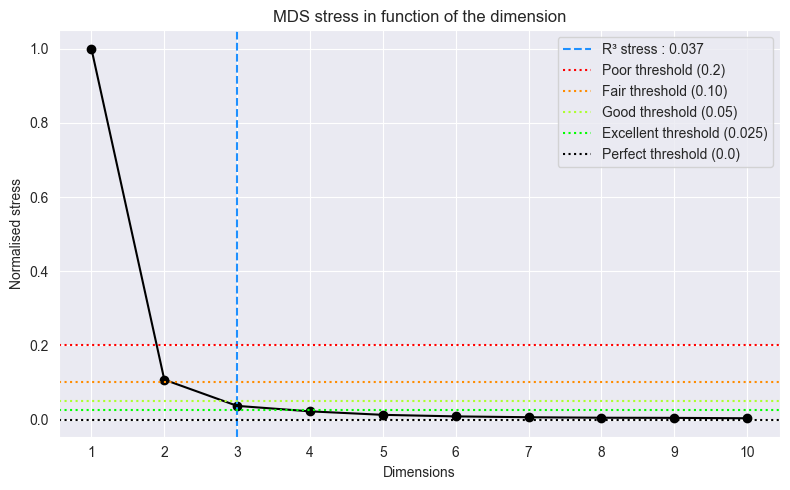

In [56]:
stress_scores = []
dimensions = range(1, 11)

for d in dimensions:
    mds = MDS(n_components=d, dissimilarity='precomputed',
              normalized_stress=False, random_state=42)
    mds.fit(mat_WD_all)
    stress_scores.append(mds.stress_)

stress_normalise = [s / stress_scores[0] for s in stress_scores]
dimensions = list(range(1, 11))

plt.figure(figsize=(8, 5))
plt.plot(dimensions, stress_normalise, marker='o', color='black')
plt.axvline(x=3, color='dodgerblue', linestyle='--', label=f'R³ stress : {round(stress_normalise[2],3)}')

plt.axhline(y=0.2, color='red', linestyle=':', label='Poor threshold (0.2)')
plt.axhline(y=0.10, color='darkorange', linestyle=':', label='Fair threshold (0.10)')
plt.axhline(y=0.05, color='greenyellow', linestyle=':', label='Good threshold (0.05)')
plt.axhline(y=0.025, color='lime', linestyle=':', label='Excellent threshold (0.025)')
plt.axhline(y=0.0, color='black', linestyle=':', label='Perfect threshold (0.0)')

plt.xlabel("Dimensions")
plt.ylabel("Normalised stress")
plt.title("MDS stress in function of the dimension")
plt.grid(True)
plt.legend()
plt.xticks(dimensions)
plt.tight_layout()
plt.show()

#stress_normalise = stress_brut / stress_dim1
dim_1 = stress_scores[0]
dim_3 = stress_scores[2]
normalised_stress_score = dim_3 / dim_1